# Phase 2 — Demographic Forecasting

Prophet (primary) vs SARIMA (benchmark).
Train on 1980–2017, test on 2018–2023, project to 2035 with 80% and 95% CIs.

**Data sources:**
- NCES 303.10: total fall enrollment in degree-granting institutions (1980–2030)
- NCES 219.10: high school graduates (1986–2031)
- IPEDS EFFY 2018–2022: enrollment by race/ethnicity

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.utils import set_seeds, OUTPUT_DIR
from src.forecasting import (
    load_total_enrollment, load_hs_graduates, load_ipeds_race_enrollment,
    _to_prophet_df, train_prophet, train_sarima,
    evaluate_models, generate_forecast, run_phase2,
    TRAIN_END, TEST_START, TEST_END, HORIZON_END, RACE_COLS,
)

set_seeds()
sns.set_theme(style='whitegrid', palette='tab10')
FIGSIZE = (14, 5)

NumExpr defaulting to 16 threads.


## 1. Load and Explore Historical Data

In [2]:
enroll_df = load_total_enrollment()
hs_df = load_hs_graduates()
race_df = load_ipeds_race_enrollment()

print('Enrollment shape:', enroll_df.shape, 'years:', enroll_df['year'].min(), '-', enroll_df['year'].max())
print('HS Graduates shape:', hs_df.shape, 'years:', hs_df['year'].min(), '-', hs_df['year'].max())
print('Race enrollment shape:', race_df.shape)
enroll_df.tail()

Enrollment shape: (51, 3) years: 1980 - 2030
HS Graduates shape: (46, 3) years: 1986 - 2031
Race enrollment shape: (5, 11)


,year,enrollment,is_projected
46,2026,20054000.0,True
47,2027,20169000.0,True
48,2028,20282000.0,True
49,2029,20393000.0,True
50,2030,20482000.0,True


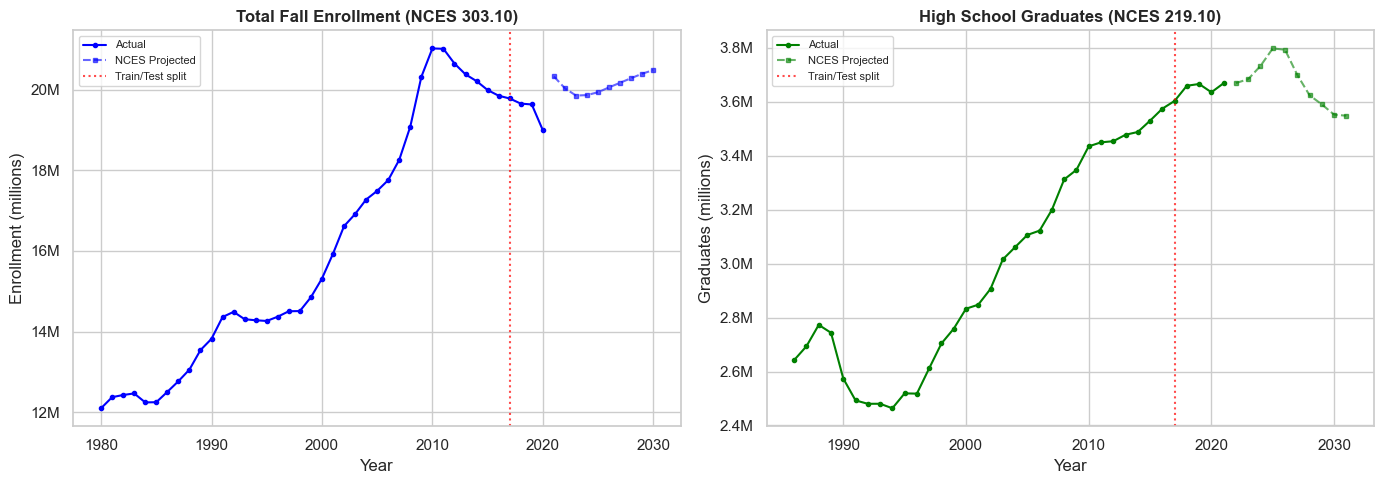

In [3]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Total enrollment
ax = axes[0]
actual = enroll_df[~enroll_df['is_projected']]
projected = enroll_df[enroll_df['is_projected']]
ax.plot(actual['year'], actual['enrollment'] / 1e6, 'b-o', markersize=3, label='Actual')
ax.plot(projected['year'], projected['enrollment'] / 1e6, 'b--s', markersize=3, alpha=0.6, label='NCES Projected')
ax.axvline(TRAIN_END, color='red', linestyle=':', alpha=0.7, label='Train/Test split')
ax.set_title('Total Fall Enrollment (NCES 303.10)', fontweight='bold')
ax.set_ylabel('Enrollment (millions)')
ax.set_xlabel('Year')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# HS graduates
ax = axes[1]
hs_actual = hs_df[~hs_df['is_projected']]
hs_proj = hs_df[hs_df['is_projected']]
ax.plot(hs_actual['year'], hs_actual['hs_graduates'] / 1e6, 'g-o', markersize=3, label='Actual')
ax.plot(hs_proj['year'], hs_proj['hs_graduates'] / 1e6, 'g--s', markersize=3, alpha=0.6, label='NCES Projected')
ax.axvline(TRAIN_END, color='red', linestyle=':', alpha=0.7, label='Train/Test split')
ax.set_title('High School Graduates (NCES 219.10)', fontweight='bold')
ax.set_ylabel('Graduates (millions)')
ax.set_xlabel('Year')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

plt.tight_layout()
plt.show()

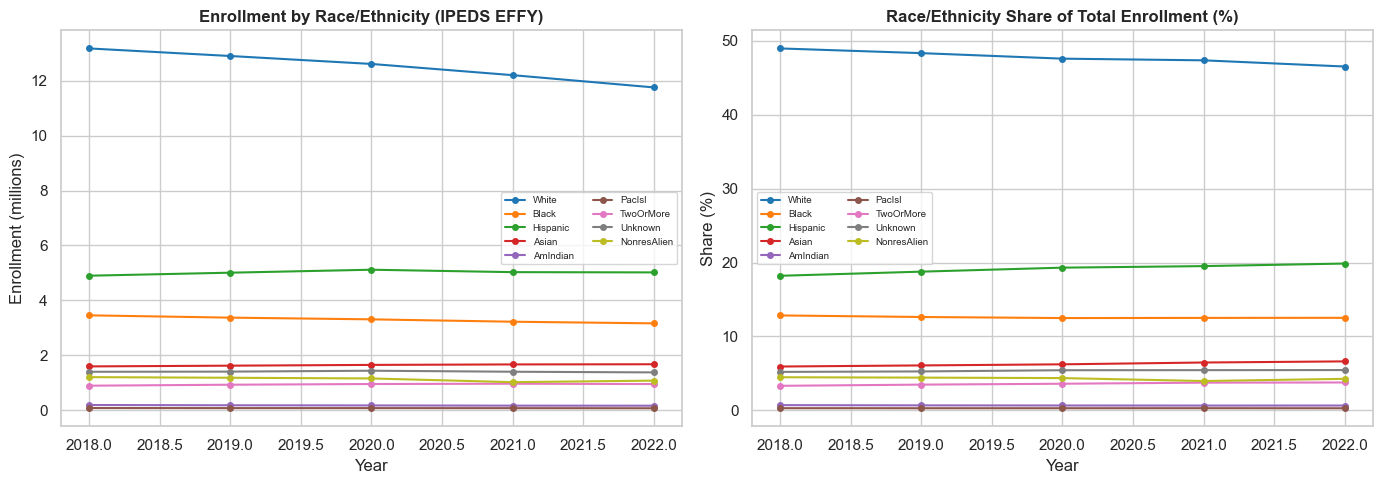

2018 vs 2022 share change:


White         -2.45
Black         -0.32
NonresAlien   -0.22
AmIndian      -0.05
PacIsl        -0.01
Unknown        0.25
TwoOrMore      0.45
Asian          0.69
Hispanic       1.66
dtype: float64

In [4]:
# Race/ethnicity composition from IPEDS EFFY 2018-2022
race_groups = list(RACE_COLS.keys())
race_plot = race_df.set_index('year')[race_groups]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Absolute numbers
ax = axes[0]
for col in race_groups:
    ax.plot(race_df['year'], race_df[col] / 1e6, marker='o', markersize=4, label=col)
ax.set_title('Enrollment by Race/Ethnicity (IPEDS EFFY)', fontweight='bold')
ax.set_ylabel('Enrollment (millions)')
ax.set_xlabel('Year')
ax.legend(fontsize=7, ncol=2)

# Share of total
ax = axes[1]
shares = race_plot.div(race_df.set_index('year')['total'], axis=0) * 100
for col in race_groups:
    ax.plot(shares.index, shares[col], marker='o', markersize=4, label=col)
ax.set_title('Race/Ethnicity Share of Total Enrollment (%)', fontweight='bold')
ax.set_ylabel('Share (%)')
ax.set_xlabel('Year')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

print('2018 vs 2022 share change:')
s18 = shares.loc[2018]
s22 = shares.loc[2022]
(s22 - s18).sort_values().round(2)

## 2. Train Prophet and SARIMA Models

In [5]:
# Prepare training set for total enrollment (1980-2017)
train_enroll = enroll_df[enroll_df['year'] <= TRAIN_END].dropna(subset=['enrollment']).copy()
print(f'Enrollment train: {len(train_enroll)} years ({train_enroll["year"].min()}–{train_enroll["year"].max()})')

train_enroll_p = _to_prophet_df(train_enroll, 'year', 'enrollment')

print('Training Prophet (80% CI)...')
m_enroll_80 = train_prophet(train_enroll_p, interval_width=0.80)
print('Training Prophet (95% CI)...')
m_enroll_95 = train_prophet(train_enroll_p, interval_width=0.95)

print('Training SARIMA(1,1,1)...')
sarima_enroll = train_sarima(pd.Series(train_enroll['enrollment'].values))
print(f'SARIMA AIC: {sarima_enroll.aic:.1f}')

Enrollment train: 38 years (1980–2017)
Training Prophet (80% CI)...


Training Prophet (95% CI)...


Training SARIMA(1,1,1)...
SARIMA AIC: 1071.9


In [6]:
# HS graduates models
train_hs = hs_df[hs_df['year'] <= TRAIN_END].dropna(subset=['hs_graduates']).copy()
print(f'HS Grad train: {len(train_hs)} years ({train_hs["year"].min()}–{train_hs["year"].max()})')

train_hs_p = _to_prophet_df(train_hs, 'year', 'hs_graduates')
print('Training HS grad Prophet...')
m_hs_80 = train_prophet(train_hs_p, interval_width=0.80)
m_hs_95 = train_prophet(train_hs_p, interval_width=0.95)

print('Training HS grad SARIMA...')
sarima_hs = train_sarima(pd.Series(train_hs['hs_graduates'].values))
print(f'SARIMA AIC: {sarima_hs.aic:.1f}')

HS Grad train: 32 years (1986–2017)
Training HS grad Prophet...


Training HS grad SARIMA...
SARIMA AIC: 787.1


## 3. Test Set Evaluation (2018–2023)

In [7]:
metrics_enroll = evaluate_models(enroll_df, m_enroll_80, sarima_enroll, 'year', 'enrollment')
metrics_hs = evaluate_models(hs_df, m_hs_80, sarima_hs, 'year', 'hs_graduates')

metrics_table = pd.DataFrame({
    'Metric': ['MAPE (%)', 'RMSE', 'Direction Accuracy'],
    'Enrollment Prophet': [
        f"{metrics_enroll.get('prophet_mape', float('nan')):.2f}%",
        f"{metrics_enroll.get('prophet_rmse', float('nan')):,.0f}",
        f"{metrics_enroll.get('prophet_direction_acc', float('nan')):.0%}",
    ],
    'Enrollment SARIMA': [
        f"{metrics_enroll.get('sarima_mape', float('nan')):.2f}%",
        f"{metrics_enroll.get('sarima_rmse', float('nan')):,.0f}",
        f"{metrics_enroll.get('sarima_direction_acc', float('nan')):.0%}",
    ],
    'HS Grad Prophet': [
        f"{metrics_hs.get('prophet_mape', float('nan')):.2f}%",
        f"{metrics_hs.get('prophet_rmse', float('nan')):,.0f}",
        f"{metrics_hs.get('prophet_direction_acc', float('nan')):.0%}",
    ],
    'HS Grad SARIMA': [
        f"{metrics_hs.get('sarima_mape', float('nan')):.2f}%",
        f"{metrics_hs.get('sarima_rmse', float('nan')):,.0f}",
        f"{metrics_hs.get('sarima_direction_acc', float('nan')):.0%}",
    ],
})
metrics_table

,Metric,Enrollment Prophet,Enrollment SARIMA,HS Grad Prophet,HS Grad SARIMA
0,MAPE (%),13.19%,3.92%,1.75%,1.19%
1,RMSE,"2,649,122","875,620","75,487","48,530"
2,Direction Accuracy,20%,20%,80%,80%


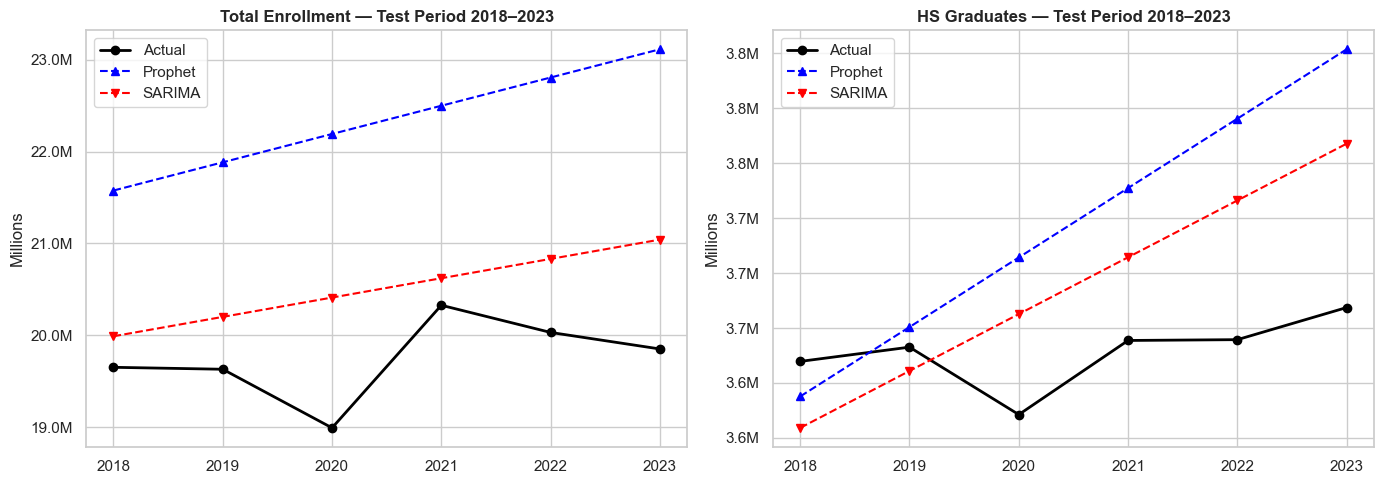

Note: Both models over-predict — trained on 1980-2017 growth trend, enrollment stagnated 2010-onward. SARIMA closer due to recent-lag dynamics.


In [8]:
# Visual: actual vs predicted on test period
test_years = list(range(TEST_START, TEST_END + 1))
future_test = pd.DataFrame({'ds': pd.to_datetime([f'{y}-12-31' for y in test_years])})

enroll_prophet_pred = m_enroll_80.predict(future_test)['yhat'].values
enroll_sarima_pred = sarima_enroll.forecast(steps=len(test_years)).values
enroll_actual = enroll_df[enroll_df['year'].between(TEST_START, TEST_END)]['enrollment'].values

hs_prophet_pred = m_hs_80.predict(future_test)['yhat'].values
hs_sarima_pred = sarima_hs.forecast(steps=len(test_years)).values
hs_actual = hs_df[hs_df['year'].between(TEST_START, TEST_END)]['hs_graduates'].values

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
for ax, actual_v, prophet_v, sarima_v, title, unit in [
    (axes[0], enroll_actual, enroll_prophet_pred, enroll_sarima_pred, 'Total Enrollment', 1e6),
    (axes[1], hs_actual, hs_prophet_pred, hs_sarima_pred, 'HS Graduates', 1e6),
]:
    ax.plot(test_years, actual_v / unit, 'ko-', label='Actual', linewidth=2)
    ax.plot(test_years, prophet_v / unit, 'b--^', label='Prophet', linewidth=1.5)
    ax.plot(test_years, sarima_v / unit, 'r--v', label='SARIMA', linewidth=1.5)
    ax.set_title(f'{title} — Test Period 2018–2023', fontweight='bold')
    ax.set_ylabel('Millions')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

plt.tight_layout()
plt.show()
print('Note: Both models over-predict — trained on 1980-2017 growth trend,'
      ' enrollment stagnated 2010-onward. SARIMA closer due to recent-lag dynamics.')

## 4. Full Forecast 2024–2035 with Confidence Intervals

In [9]:
fcast_enroll = generate_forecast(
    enroll_df, m_enroll_80, m_enroll_95, sarima_enroll,
    'year', 'enrollment', 'total_enrollment', start_year=1980,
)

fcast_hs = generate_forecast(
    hs_df, m_hs_80, m_hs_95, sarima_hs,
    'year', 'hs_graduates', 'hs_graduates', start_year=1986,
)

print('Enrollment forecast shape:', fcast_enroll.shape)
fcast_enroll[fcast_enroll['year'] >= 2024][['year', 'prophet_yhat', 'sarima_yhat',
                                             'sarima_lower_80', 'sarima_upper_80']].head(6)

Enrollment forecast shape: (56, 14)


,year,prophet_yhat,sarima_yhat,sarima_lower_80,sarima_upper_80
44,2024,2.342313e+07,2.125219e+07,2.049819e+07,2.200619e+07
45,2025,2.373066e+07,2.146230e+07,2.065640e+07,2.226819e+07
46,2026,2.403818e+07,2.167237e+07,2.081773e+07,2.252701e+07
47,2027,2.434571e+07,2.188242e+07,2.098169e+07,2.278316e+07
48,2028,2.465407e+07,2.209245e+07,2.114787e+07,2.303704e+07
49,2029,2.496160e+07,2.230248e+07,2.131600e+07,2.328895e+07


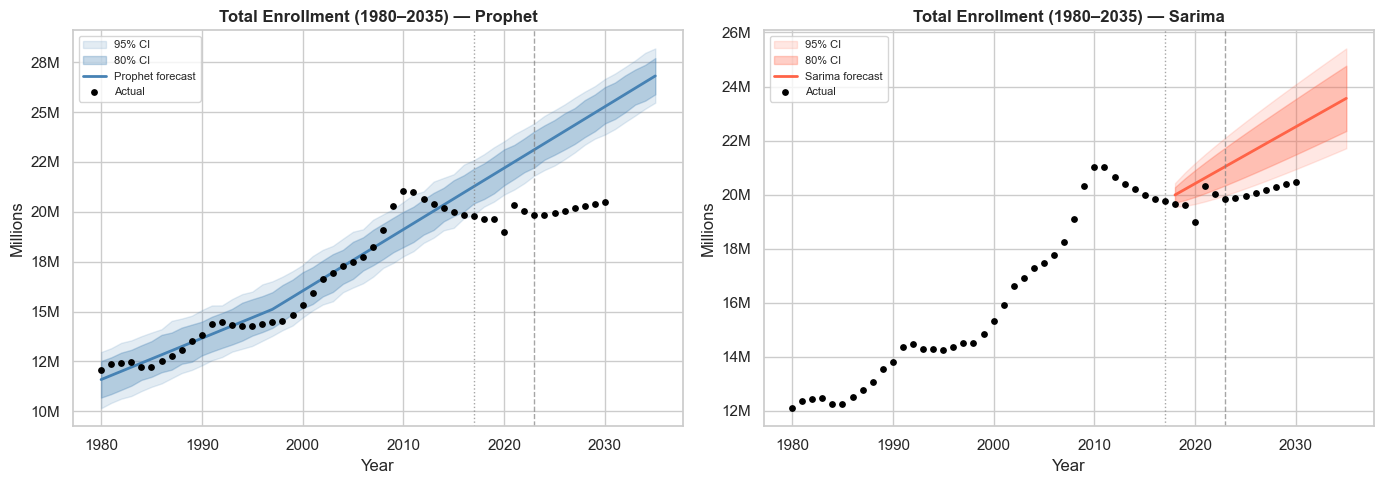

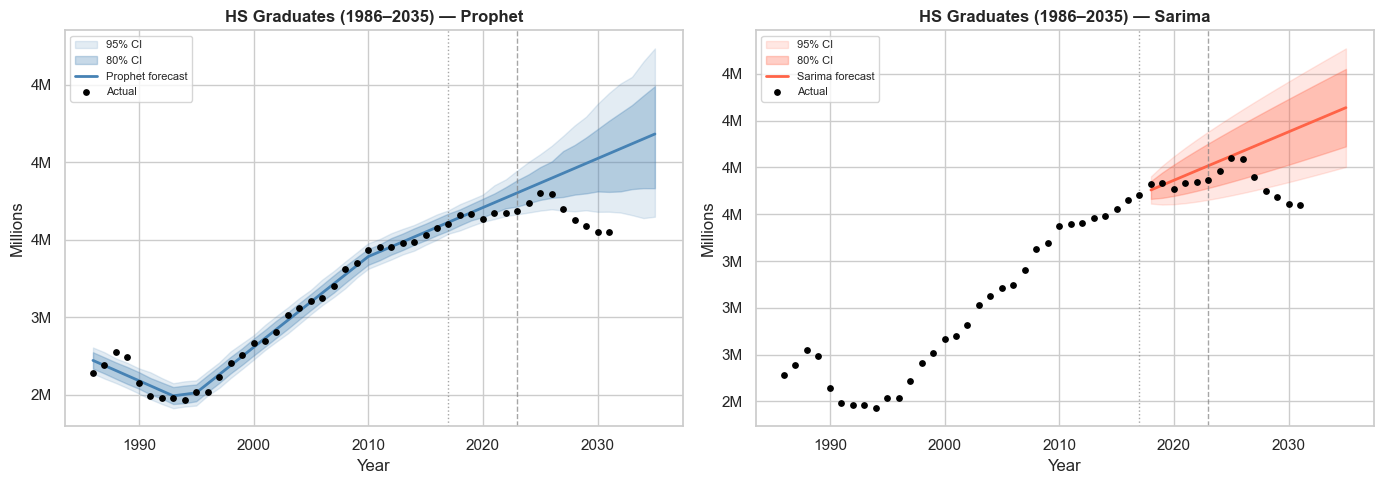

In [10]:
def plot_forecast(fcast: pd.DataFrame, value_name: str, unit: float = 1e6, title: str = '') -> None:
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

    for ax, model, lower_80, upper_80, lower_95, upper_95, color in [
        (axes[0], 'prophet_yhat', 'prophet_lower_80', 'prophet_upper_80',
         'prophet_lower_95', 'prophet_upper_95', 'steelblue'),
        (axes[1], 'sarima_yhat', 'sarima_lower_80', 'sarima_upper_80',
         'sarima_lower_95', 'sarima_upper_95', 'tomato'),
    ]:
        model_name = model.split('_')[0].capitalize()

        ax.fill_between(fcast['year'], fcast[lower_95] / unit, fcast[upper_95] / unit,
                        alpha=0.15, color=color, label='95% CI')
        ax.fill_between(fcast['year'], fcast[lower_80] / unit, fcast[upper_80] / unit,
                        alpha=0.3, color=color, label='80% CI')
        ax.plot(fcast['year'], fcast[model] / unit, color=color, lw=2, label=f'{model_name} forecast')
        ax.scatter(fcast['year'], fcast['actual'] / unit, color='black', s=15, zorder=5, label='Actual')
        ax.axvline(TRAIN_END, color='gray', ls=':', alpha=0.7, lw=1)
        ax.axvline(TEST_END, color='gray', ls='--', alpha=0.7, lw=1)

        ax.set_title(f'{title} — {model_name}', fontweight='bold')
        ax.set_ylabel('Millions')
        ax.set_xlabel('Year')
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

    plt.tight_layout()
    plt.show()


plot_forecast(fcast_enroll, 'enrollment', title='Total Enrollment (1980–2035)')
plot_forecast(fcast_hs, 'hs_graduates', title='HS Graduates (1986–2035)')

## 5. Race/Ethnicity Trend Projections

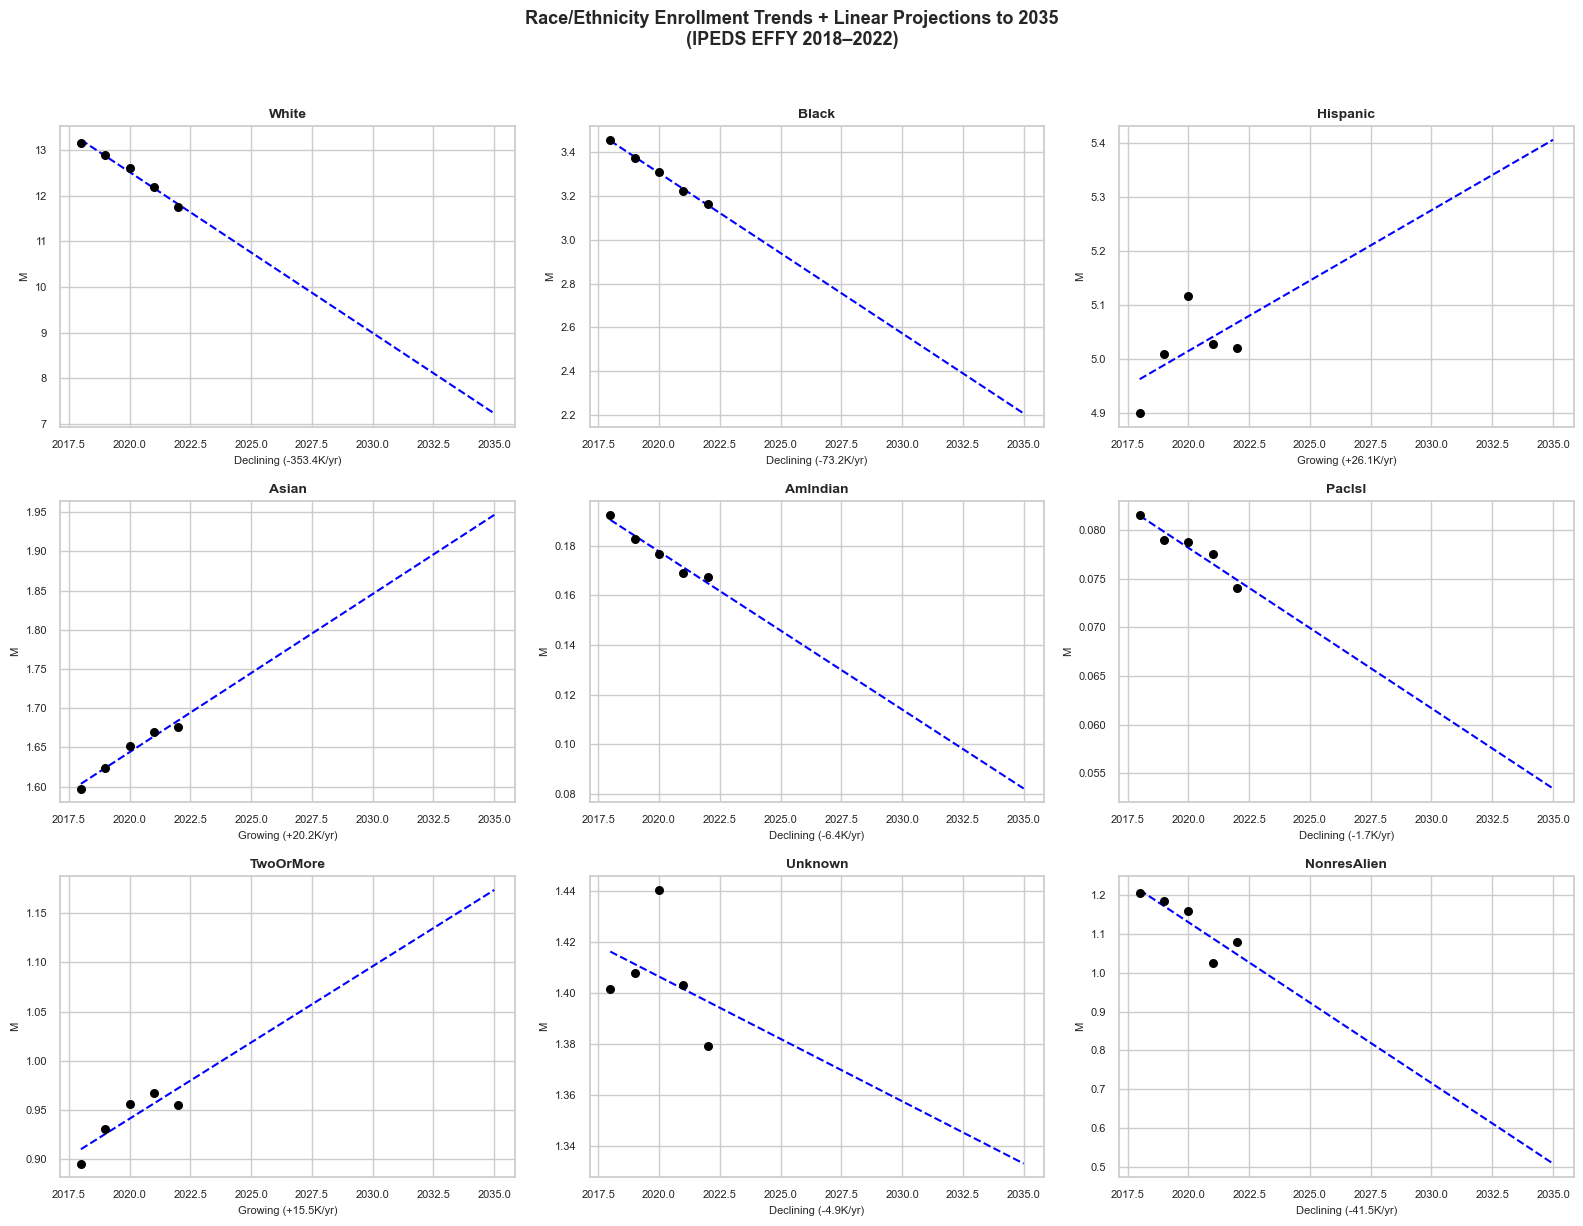

,slope,2035_proj
White,-353449.0,7223132.0
Black,-73233.0,2206925.0
Hispanic,26096.0,5405786.0
Asian,20187.0,1946657.0
AmIndian,-6368.0,82219.0
PacIsl,-1651.0,53428.0
TwoOrMore,15503.0,1173588.0
Unknown,-4899.0,1333055.0
NonresAlien,-41526.0,507985.0


In [11]:
# Linear trend projections for each race group (IPEDS EFFY 2018-2022 → 2035)
race_fcasts = {}
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (race_group, _) in enumerate(RACE_COLS.items()):
    if race_group not in race_df.columns:
        continue
    sub = race_df[['year', race_group]].dropna()
    x = sub['year'].values.astype(float)
    y = sub[race_group].values.astype(float)
    slope, intercept = np.polyfit(x, y, 1)
    
    proj_years = np.arange(2018, HORIZON_END + 1)
    proj = slope * proj_years + intercept
    race_fcasts[race_group] = {'slope': slope, '2035_proj': slope * 2035 + intercept}
    
    ax = axes_flat[i]
    ax.scatter(sub['year'], sub[race_group] / 1e6, color='black', s=30, zorder=5)
    ax.plot(proj_years, proj / 1e6, 'b--', lw=1.5)
    ax.set_title(race_group, fontweight='bold', fontsize=10)
    ax.set_ylabel('M', fontsize=8)
    ax.tick_params(labelsize=8)
    trend = 'Growing' if slope > 0 else 'Declining'
    ax.set_xlabel(f'{trend} ({slope/1000:+.1f}K/yr)', fontsize=8)

for j in range(len(RACE_COLS), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Race/Ethnicity Enrollment Trends + Linear Projections to 2035\n(IPEDS EFFY 2018–2022)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
pd.DataFrame(race_fcasts).T.round(0)

## 6. Save forecasts.csv and Print Key Findings

In [12]:
# Run full pipeline (trains both models + saves forecasts.csv)
forecasts_df, metrics_all = run_phase2(save=True)
print(f'Saved forecasts.csv: {len(forecasts_df):,} rows')
print('Series in output:', forecasts_df['series'].value_counts().to_dict())
print('Output path:', OUTPUT_DIR / 'forecasts.csv')

Fitting models for: total_enrollment


total_enrollment  prophet MAPE=13.19%  SARIMA MAPE=3.92%


Fitting models for: hs_graduates


hs_graduates  prophet MAPE=1.75%  SARIMA MAPE=1.19%


Saved forecasts.csv (268 rows)


Saved forecasts.csv: 268 rows
Series in output: {'race_enrollment': 162, 'total_enrollment': 56, 'hs_graduates': 50}
Output path: C:\Users\jeged\Downloads\Enrollment Decline & Demographic Shift AI System\data\output\forecasts.csv


In [13]:
print('=== Model Metrics (2018-2023 test set) ===')
for series, m in metrics_all.items():
    print(f'\n{series}:')
    for k, v in m.items():
        print(f'  {k}: {v:.3f}')

print('\n=== Key Findings ===')

enroll_2024 = forecasts_df[
    (forecasts_df['series'] == 'total_enrollment') & (forecasts_df['year'] == 2024)
]
enroll_2035 = forecasts_df[
    (forecasts_df['series'] == 'total_enrollment') & (forecasts_df['year'] == 2035)
]
print(f'Enrollment 2024 (SARIMA): {enroll_2024["sarima_yhat"].values[0]/1e6:.1f}M')
print(f'Enrollment 2035 (SARIMA): {enroll_2035["sarima_yhat"].values[0]/1e6:.1f}M')

# Largest growing race group by slope
race_rows = forecasts_df[(forecasts_df['series'] == 'race_enrollment') & (forecasts_df['year'] == 2024)].copy()
race_2018 = forecasts_df[(forecasts_df['series'] == 'race_enrollment') & (forecasts_df['year'] == 2018)]
race_2022 = forecasts_df[(forecasts_df['series'] == 'race_enrollment') & (forecasts_df['year'] == 2022)]
if not race_2018.empty and not race_2022.empty:
    r18 = race_2018.set_index('segment')['actual']
    r22 = race_2022.set_index('segment')['actual']
    chg = (r22 - r18).sort_values(ascending=False)
    print('\nAbsolute enrollment change 2018→2022:')
    print(chg.round(0).to_string())

=== Model Metrics (2018-2023 test set) ===

total_enrollment:
  prophet_mape: 13.186
  prophet_rmse: 2649122.281
  sarima_mape: 3.924
  sarima_rmse: 875620.121
  prophet_direction_acc: 0.200
  sarima_direction_acc: 0.200

hs_graduates:
  prophet_mape: 1.745
  prophet_rmse: 75486.677
  sarima_mape: 1.194
  sarima_rmse: 48529.973
  prophet_direction_acc: 0.800
  sarima_direction_acc: 0.800

=== Key Findings ===
Enrollment 2024 (SARIMA): 21.3M
Enrollment 2035 (SARIMA): 23.6M

Absolute enrollment change 2018→2022:
segment
Hispanic        120657.0
Asian            78321.0
TwoOrMore        59279.0
PacIsl           -7539.0
Unknown         -22298.0
AmIndian        -25060.0
NonresAlien    -127760.0
Black          -291878.0
White         -1418708.0


## 7. Phase 2 Acceptance Gates

In [14]:
checks = {
    'forecasts.csv exists': (OUTPUT_DIR / 'forecasts.csv').exists(),
    'forecasts.csv has total_enrollment series': 
        'total_enrollment' in forecasts_df['series'].values,
    'forecasts.csv has hs_graduates series': 
        'hs_graduates' in forecasts_df['series'].values,
    'forecasts.csv has race_enrollment series': 
        'race_enrollment' in forecasts_df['series'].values,
    'forecast horizon to 2035': int(forecasts_df['year'].max()) >= HORIZON_END,
    '80% CI columns present': all(
        c in forecasts_df.columns
        for c in ['prophet_lower_80', 'prophet_upper_80', 'sarima_lower_80', 'sarima_upper_80']
    ),
    '95% CI columns present': all(
        c in forecasts_df.columns
        for c in ['prophet_lower_95', 'prophet_upper_95', 'sarima_lower_95', 'sarima_upper_95']
    ),
    'SARIMA MAPE < 10% on enrollment': metrics_all.get('total_enrollment', {}).get('sarima_mape', 100) < 10,
}

for k, v in checks.items():
    print(('OK   ' if v else 'FAIL '), k)

assert all(checks.values()), 'Phase 2 acceptance failed'

OK    forecasts.csv exists
OK    forecasts.csv has total_enrollment series
OK    forecasts.csv has hs_graduates series
OK    forecasts.csv has race_enrollment series
OK    forecast horizon to 2035
OK    80% CI columns present
OK    95% CI columns present
OK    SARIMA MAPE < 10% on enrollment
